# Executing QIR programs

If you have a QIR string or bitcode, you can start by creating Pulla-compatible circuits representation. You can also generate a QIR string or bitcode from a qiskit circuit using IQM's fork of `qiskit_qir`, available as the package `iqm-qiskit-qir`.

In [1]:
from qiskit import QuantumCircuit, visualization
from qiskit.compiler import transpile
from qiskit_qir import to_qir_module

from iqm.pulla.pulla import Pulla
from iqm.pulla.utils_qiskit import sweep_job_to_qiskit
from iqm.pulla.utils_qir import qir_to_pulla, generate_qiskit_qir_qubit_mapping
from iqm.iqm_client.util import print_env_vars
from iqm.qiskit_iqm import IQMProvider
from iqm.station_control.interface.models import MoveGateFrameTrackingMode

In [ ]:
# Create a Pulla object and a qiskit-iqm backend for accessing the quantum computer.
print_env_vars()

p = Pulla()
provider = IQMProvider()
backend = provider.get_backend()
compiler = p.get_standard_compiler()

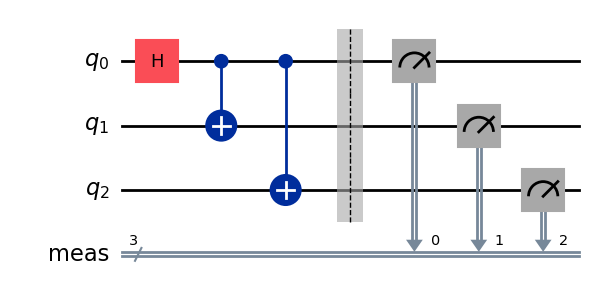

In [3]:
# Define a quantum circuit (for visualization).
qc = QuantumCircuit(3)
qc.h(0)
qc.cx(0, 1)
qc.cx(0, 2)
qc.measure_all()
qc.draw(output='mpl')

In [4]:
# Transpile the circuit using Qiskit
qc_transpiled = transpile(qc, backend=backend, layout_method='sabre', optimization_level=3)
print(qc_transpiled.draw(output='text'))

#Generate the QIR
module, _ = to_qir_module(qc_transpiled, "BasicExecution")
qir = str(module)

               ┌─────────────┐                  ┌─────────────┐ ░       ┌─┐
      q_0 -> 2 ┤ R(π/2,3π/2) ├──────────■───────┤ R(π/2,5π/2) ├─░───────┤M├
               ├─────────────┤          │       └─────────────┘ ░ ┌─┐   └╥┘
      q_2 -> 0 ┤ R(π/2,3π/2) ├─■────────■───────────────────────░─┤M├────╫─
               ├─────────────┤ │ ┌─────────────┐                ░ └╥┘┌─┐ ║ 
ancilla_0 -> 1 ┤ R(π/2,3π/2) ├─■─┤ R(π/2,5π/2) ├────────────────░──╫─┤M├─╫─
               └─────────────┘   └─────────────┘                ░  ║ └╥┘ ║ 
       meas: 3/════════════════════════════════════════════════════╩══╩══╩═
                                                                   0  1  2 


In [5]:
# qiskit-qir has a bug, which causes qubit pointers to not be generated correctly
qubits_mapping = generate_qiskit_qir_qubit_mapping(qc_transpiled, backend)

## Executing QIR

[06-08 19:18:33;I] Required number of qubits: 5
[06-08 19:18:33;I] Required number of results: 3
[06-08 19:18:33;I] QIR version: 1.0


/home/ville/iqm/repot/continuous-delivery/iqm-qccsw/iqm-pulla/src/iqm/pulla/utils_qir.py:195: UserWarning: custom may not be a supported QIR profile
  warnings.warn(f"{_qir_profiles} may not be a supported QIR profile")


[06-08 19:18:33;I] Waiting for job 019ea807-56fb-7ae3-a35a-093a3e88f9e2 to finish...


Progress in queue:   0%|          | 0/1 [00:00<?, ?it/s]

Qiskit result counts: {'0 0 0': 2232, '1 1 1': 1778, '0 1 1': 177, '0 1 0': 318, '1 0 0': 171, '1 0 1': 191, '0 0 1': 23, '1 1 0': 110}


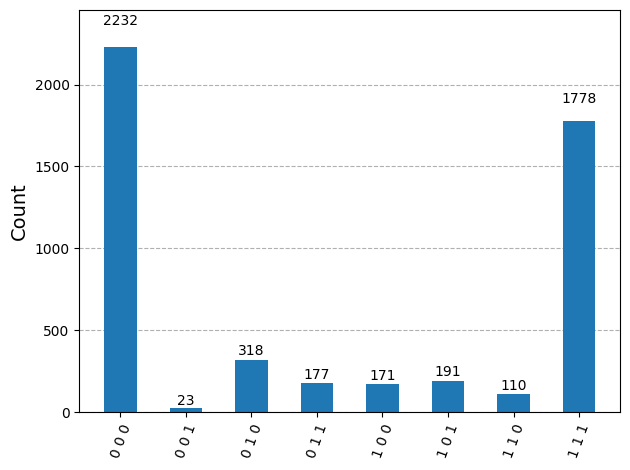

In [6]:
# Pass qubit mapping to qir_to_pulla converter to correctly interpret opaque qubit pointer indices in QIR
# and convert them to physical IQM qubit names.
circuits, _ = qir_to_pulla(compiler, qir, qubits_mapping)

# Get settings from the compiler
settings = compiler.get_settings(circuits=circuits)

# Configure settings as in other notebooks
settings.stages.timebox_stage.prepend_heralding.add_heralding = False
settings.stages.circuit_resolution.resolve_circuits.scheduling_strategy = "ASAP"
settings.stages.circuit_stage.subscribe_and_probe.convert_terminal_measurements = True
settings.stages.schedule_stage.apply_move_gate_phase_corrections.move_gate_frame_tracking_mode = MoveGateFrameTrackingMode.FULL
settings.stages.circuit_stage.subscribe_and_probe.probe_all = False

shots = 5000
settings.set_shots(shots)

# Compile and submit
job_definition, context = compiler.compile(circuits=circuits, settings=settings)
job = p.submit_playlist(job_definition, context=context)
job.wait_for_completion()

# Retrieve results using qiskit-iqm integration
qiskit_result = sweep_job_to_qiskit(job, shots=shots)
print(f"Qiskit result counts: {qiskit_result.get_counts()}")
visualization.plot_histogram(qiskit_result.get_counts())